In [ ]:
import pandas as pd
import pickle
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split


In [23]:
df = pd.read_csv("human_bot_typing_dataset.csv")

In [24]:
print(df.head())

   Average_Dwell_Time  Average_Flight_Time  Flight_Time_Std_Dev  \
0           55.392391             8.705488             7.292178   
1           66.366217            12.691118             3.825088   
2          124.486953            57.133349            18.097768   
3           58.085511            10.070682             7.680555   
4           89.131769            47.823700             0.908359   

   Words_Per_Minute  Human_Like_Typing_Score  Label  
0        118.199357                 0.364419    0.0  
1        159.114257                 0.475274    0.0  
2         62.141283                 0.762071    1.0  
3        142.660258                 0.267970    0.0  
4         65.955731                 0.763523    1.0  


In [25]:
FEATURES = ["Average_Dwell_Time", "Average_Flight_Time", "Flight_Time_Std_Dev", "Words_Per_Minute", "Human_Like_Typing_Score"]

In [26]:
X = df[FEATURES]

In [27]:
y = data["Label"]

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [29]:
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [30]:
with open("model.pkl", "wb") as f:
    pickle.dump(clf, f)

In [31]:
print("✅ Model trained and saved as 'model.pkl'")

✅ Model trained and saved as 'model.pkl'


In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pickle

# Load the dataset
df = pd.read_csv('ketstokes.csv')

# Define the features and target variable
features = ['Average_Dwell_Time', 'Average_Flight_Time', 'Flight_Time_Std_Dev', 'Human_Like_Typing_Score', 'Words_Per_Minute']
X = df[features]
y = df['Label'].map({'human': 0, 'bot': 1})  # Map labels to numeric values

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the Random Forest classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
clf.fit(X_train, y_train)

# Predict on the test set
y_pred = clf.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Save the trained model using pickle
with open('random_forest_model.pkl', 'wb') as model_file:
    pickle.dump(clf, model_file)

print("Model saved as 'random_forest_model.pkl'.")


Accuracy: 1.0
Confusion Matrix:
[[100027      0]
 [     0  99973]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    100027
           1       1.00      1.00      1.00     99973

    accuracy                           1.00    200000
   macro avg       1.00      1.00      1.00    200000
weighted avg       1.00      1.00      1.00    200000

Model saved as 'random_forest_model.pkl'.


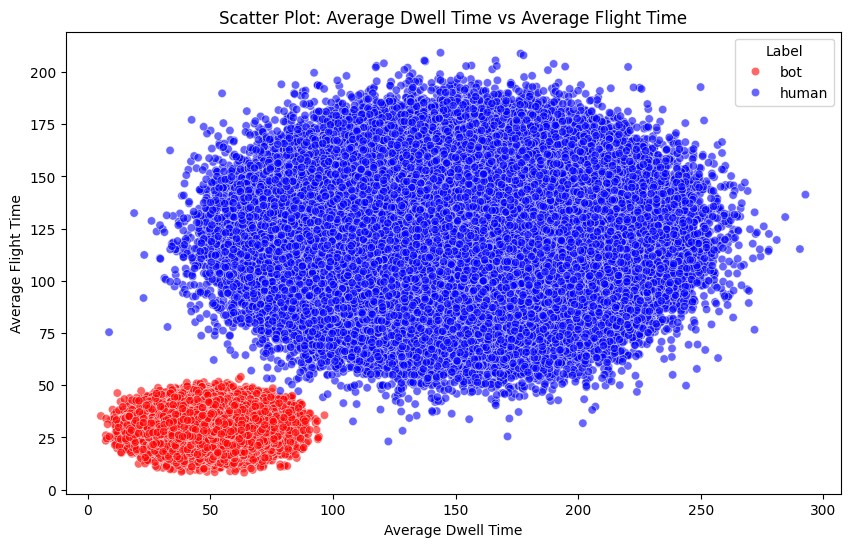

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('ketstokes.csv')

# Create a scatter plot using seaborn for a clear visualization.
# Here we're plotting Average_Dwell_Time vs. Average_Flight_Time
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df, 
    x='Average_Dwell_Time', 
    y='Average_Flight_Time', 
    hue='Label', 
    palette={'human': 'blue', 'bot': 'red'},
    alpha=0.6
)
plt.title('Scatter Plot: Average Dwell Time vs Average Flight Time')
plt.xlabel('Average Dwell Time')
plt.ylabel('Average Flight Time')
plt.legend(title='Label')
plt.show()
